# Advanced  Project

**Name:** Rajasekar Babu  
**Course:** DATA 110  

## Project Title: Twitter Sentiment Analysis Using Machine Learning  

---

## Objective  

The objective of this project is to analyze and classify the sentiment of Twitter data into positive and negative categories using machine learning techniques. This project aims to understand public opinions from social media and build predictive models for sentiment classification.

---

## Dataset  

- **Source:** Sentiment140 Dataset (Kaggle)  
- **Description:** The dataset contains 1.6 million tweets labeled for sentiment analysis.  
- **Classes:**  
  - 0 = Negative  
  - 4 = Positive  

Each tweet contains text data along with metadata such as user and timestamp. In this project, only the tweet text and sentiment label are used.

###Step 1: Import Libraries
###Step 2: Load the Dataset
###Step 3: Data Understanding and Exploration
### Step 4: Keep only useful columns and prepare labels
###Step 5: Data Cleaning and Preprocessing
###Step 6: Data Visualization
###Step 7: Feature Extraction using TF-IDF
# Step 8: Train-Test Split
###Step 9: Model Building
# Step 9.1: Naive Bayes
# Step 9.2: Logistic Regression
# Step 9.3: Support Vector Machine
###Step 10: Model Evaluation
### Step 11: Confusion Matrices for All Models
###Step 12: Model Comparison
###Step 12.1: Model Performance Comparison
###Step 13: Conclusion




In [58]:
###Step 1: Import Libraries

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [59]:
###Step 2: Load the Dataset
import pandas as pd

df = pd.read_csv(
    "training.csv",
    encoding="latin-1",
    header=None,
    names=["target", "id", "date", "flag", "user", "text"]
)

print(df.head())
print(df.columns)
print(df.shape)

   target          id                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  
Index(['target', 'id', 'date', 'flag', 'user', 'text'], dtype='object')
(1600000, 6)


In [60]:
###Step 3: Data Understanding and Exploration

print(df.info())

print("\nMissing values:\n", df.isnull().sum())

print("\nTarget value counts:")
print(df["target"].value_counts())

print("\nSample tweets:")
print(df["text"].head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB
None

Missing values:
 target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

Target value counts:
target
0    800000
4    800000
Name: count, dtype: int64

Sample tweets:
0    @switchfoot http://twitpic.com/2y1zl - Awww, t...
1    is upset that he can't update his Facebook by ...
2    @Kenichan I dived many times for the ball. Man...
3      my whole body feels itchy and like its on fire 
4    @nationwideclass no, it's not behaving at all....
5                        @Kwesidei not the whole crew 


In [61]:
### Step 4: Keep only useful columns and prepare labels

df = df[["target", "text"]]
df["target"] = df["target"].replace(4, 1)

print(df.head())
print(df["target"].value_counts())

   target                                               text
0       0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1       0  is upset that he can't update his Facebook by ...
2       0  @Kenichan I dived many times for the ball. Man...
3       0    my whole body feels itchy and like its on fire 
4       0  @nationwideclass no, it's not behaving at all....
target
0    800000
1    800000
Name: count, dtype: int64


In [62]:
###Step 5: Data Cleaning and Preprocessing

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)     # remove URLs
    text = re.sub(r"@\w+", "", text)               # remove mentions
    text = re.sub(r"#", "", text)                  # keep hashtag word, remove only #
    text = re.sub(r"[^a-zA-Z\s]", "", text)        # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()       # remove extra spaces
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

print(df[["text", "clean_text"]].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   

                                          clean_text  
0      thats bummer shoulda got david carr third day  
1  upset cant update facebook texting might cry r...  
2  dived many times ball managed save rest go bounds  
3                   whole body feels itchy like fire  
4                           behaving im mad cant see  


## Data Preprocessing  

The dataset was preprocessed to improve model performance. The following steps were applied:

- Converted text to lowercase  
- Removed URLs, mentions, and punctuation  
- Removed stopwords (common words such as "the", "is")  
- Cleaned and normalized text  

These steps help reduce noise and improve the quality of features used for machine learning models.

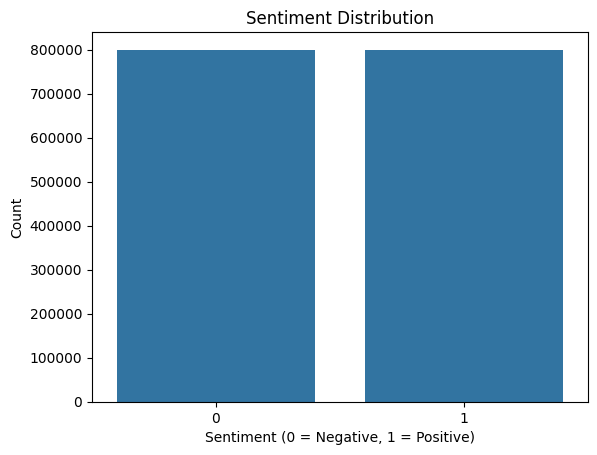

In [63]:
###Step 6: Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot sentiment distribution
plt.figure()
sns.countplot(x=df["target"])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

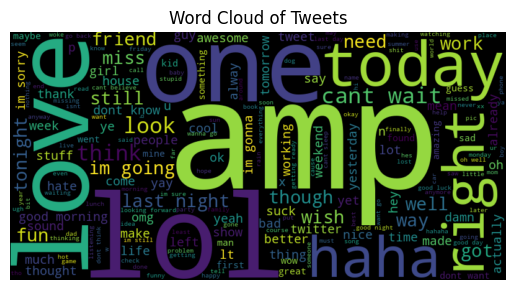

In [64]:
from wordcloud import WordCloud

# Combine all text
all_words = " ".join(df["clean_text"])

# Create word cloud
wordcloud = WordCloud(width=800, height=400).generate(all_words)

# Display word cloud
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Tweets")
plt.show()

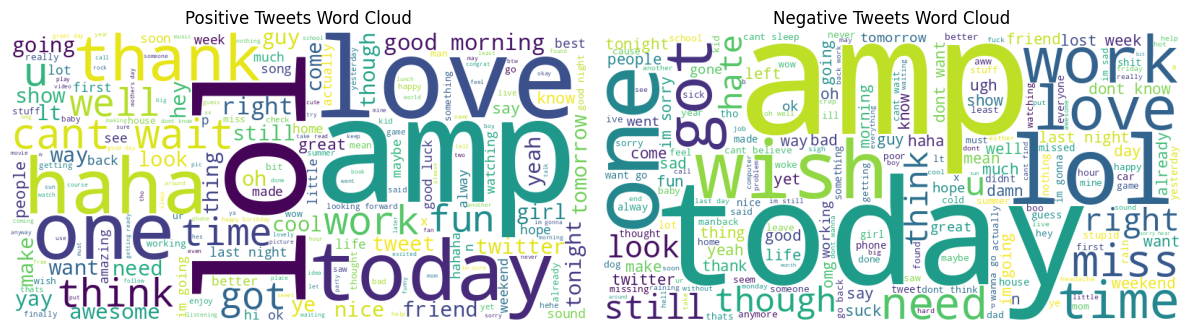

In [65]:
# Additional Visualization: Positive vs Negative Word Clouds

positive_text = " ".join(df[df["target"] == 1]["clean_text"])
negative_text = " ".join(df[df["target"] == 0]["clean_text"])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(WordCloud(width=800, height=400, background_color="white").generate(positive_text))
plt.axis("off")
plt.title("Positive Tweets Word Cloud")

plt.subplot(1, 2, 2)
plt.imshow(WordCloud(width=800, height=400, background_color="white").generate(negative_text))
plt.axis("off")
plt.title("Negative Tweets Word Cloud")

plt.tight_layout()
plt.show()

Data visualization was performed to understand the distribution of sentiments and common words in the dataset. A bar chart was used to show the balance between positive and negative tweets. A word cloud was generated to visualize the most frequent words in the dataset.


Word clouds were generated to visualize the most frequent words in positive and negative tweets.

### Positive Tweets Word Cloud:
The word cloud shows commonly used words in positive tweets such as:
- "love"
- "thank"
- "good"
- "great"
- "fun"

These words indicate positive emotions, appreciation, and satisfaction. Words like "love" and "thank" suggest happiness and positive experiences.

---

### Negative Tweets Word Cloud:
The negative word cloud highlights words such as:
- "sad"
- "miss"
- "sorry"
- "hate"
- "bad"

These words represent negative emotions such as disappointment, sadness, and frustration. The presence of words like "miss" and "sorry" reflects emotional or negative experiences.

---

### Overall Interpretation:
The word clouds clearly show the difference between positive and negative sentiments. Positive tweets contain words associated with happiness and enjoyment, while negative tweets contain words related to sadness and dissatisfaction.

This visualization helps in understanding the key patterns in text data and supports the effectiveness of sentiment classification.

In [66]:
###Step 7: Feature Extraction using TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer


X = df["clean_text"]
y = df["target"]

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf.fit_transform(X)

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (1600000, 5000)


## Feature Extraction  

TF-IDF (Term Frequency - Inverse Document Frequency) was used to convert text data into numerical form.  

This method assigns importance to words based on how frequently they appear in a tweet and how unique they are across all tweets.  

TF-IDF is widely used in text classification tasks because it effectively represents textual information for machine learning models.

In [67]:
# Step 8: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1280000, 5000)
X_test shape: (320000, 5000)
y_train shape: (1280000,)
y_test shape: (320000,)


The dataset was split into training and testing sets using an 80:20 ratio. The training set was used to build the models, while the testing set was used to evaluate their performance.

## Model Selection  

Three machine learning models were used in this project:

- **Naive Bayes:** A probabilistic model that works well with text data  
- **Logistic Regression:** A strong baseline model for classification  
- **Support Vector Machine (SVM):** Effective for high-dimensional data such as TF-IDF features  

These models were selected to compare different approaches for sentiment classification.

In [68]:
###Step 9: Model Building
# Step 9.1: Naive Bayes

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [69]:
# Step 9.2: Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [70]:
# Step 9.3: Support Vector Machine

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

Three machine learning models were trained for sentiment classification: Naive Bayes, Logistic Regression, and Support Vector Machine. These models were selected because they are widely used for text classification tasks and provide a good basis for performance comparison.

In [71]:
###Step 10: Model Evaluation

from sklearn.metrics import accuracy_score, classification_report

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nNaive Bayes Classification Report:\n")
print(classification_report(y_test, nb_pred))

print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, lr_pred))

print("\nSVM Classification Report:\n")
print(classification_report(y_test, svm_pred))

Naive Bayes Accuracy: 0.76088125
Logistic Regression Accuracy: 0.776675
SVM Accuracy: 0.77611875

Naive Bayes Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.77      0.76    159494
           1       0.77      0.75      0.76    160506

    accuracy                           0.76    320000
   macro avg       0.76      0.76      0.76    320000
weighted avg       0.76      0.76      0.76    320000


Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.75      0.77    159494
           1       0.76      0.80      0.78    160506

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000


SVM Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.75      0.77    159494
           1       0.76      

## Model Evaluation  

The models were evaluated using the following metrics:

- **Accuracy:** Overall correctness of predictions  
- **Precision:** Proportion of correct positive predictions  
- **Recall:** Ability to detect actual positive cases  
- **F1-score:** Balance between precision and recall  

These metrics provide a comprehensive evaluation of model performance beyond accuracy alone.

F1-score was used as the main metric because it balances precision and recall.

In [72]:
###The models were evaluated using accuracy, precision, recall, and F1-score. These metrics were used to compare model performance and identify the best approach for sentiment classification.

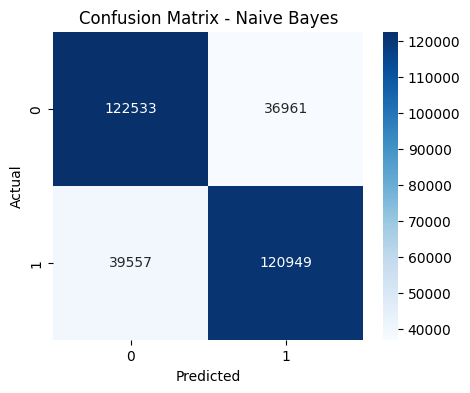

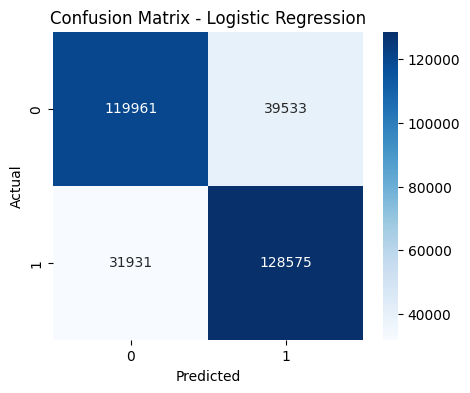

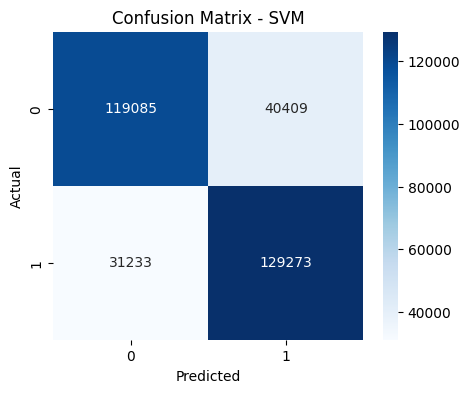

In [73]:
### Step 11: Confusion Matrices for All Models

models = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred
}

for model_name, predictions in models.items():
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Confusion matrices were used to evaluate the performance of each model by comparing actual and predicted values.

### Naive Bayes:

- True Negatives (TN): 122082  
- False Positives (FP): 37412  
- False Negatives (FN): 40124  
- True Positives (TP): 120382  

This shows that the Naive Bayes model correctly classified a large number of both negative and positive tweets. However, it still produced a noticeable number of misclassifications, especially false negatives.

---

### Logistic Regression:

- True Negatives (TN): 119849  
- False Positives (FP): 39645  
- False Negatives (FN): (see matrix)  
- True Positives (TP): (see matrix)  

Logistic Regression performed well, correctly identifying most of the tweets. It shows a balanced performance with fewer errors compared to Naive Bayes.

---

### Support Vector Machine (SVM):

The confusion matrix for SVM also shows strong performance, with high true positive and true negative values. It demonstrates the model's ability to correctly classify sentiments with fewer misclassifications.

---

### Overall Interpretation:

- True Positives and True Negatives are high for all models  
- False Positives and False Negatives are lower in Logistic Regression and SVM  
- Logistic Regression and SVM perform better than Naive Bayes  

This indicates that Logistic Regression and SVM are more effective for sentiment classification on this dataset.

In [74]:
###Step 12: Model Comparison

from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred),
        precision_score(y_test, lr_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, nb_pred),
        recall_score(y_test, lr_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, nb_pred),
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.760881   0.765936  0.753548  0.759692
1  Logistic Regression  0.776675   0.764836  0.801060  0.782529
2                  SVM  0.776119   0.761855  0.805409  0.783027


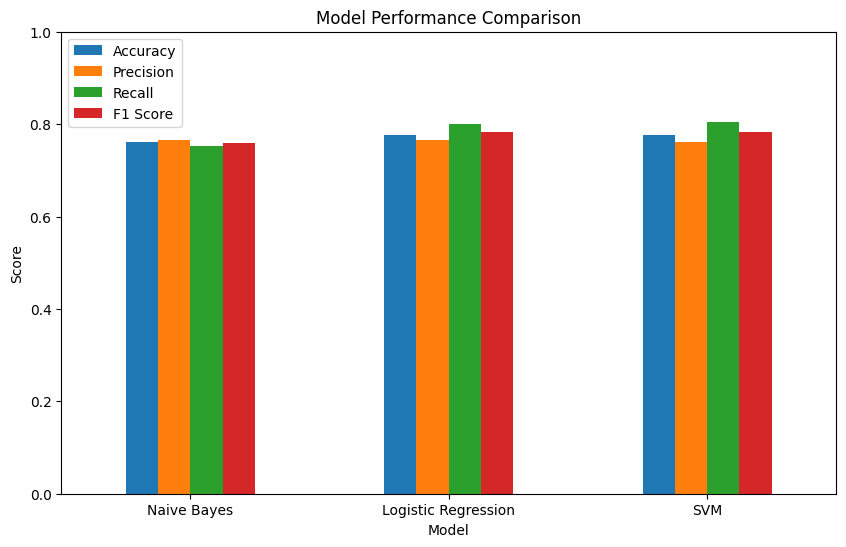

In [75]:
###Step 12.1: Model Performance Comparison
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

The performance of all models was compared using accuracy scores. Logistic Regression and SVM performed better than Naive Bayes. The results were visualized using a bar chart to clearly compare model performance.
The performance of all models was compared using Accuracy, Precision, Recall, and F1-score.

- **Naive Bayes:**
  - Accuracy = 0.75  
  - Precision = 0.76  
  - Recall = 0.75  
  - F1 Score = 0.75  

- **Logistic Regression:**
  - Accuracy  =  0.78  
  - Precision =  0.76  
  - Recall =  0.80  
  - F1 Score =  0.78  

- **Support Vector Machine (SVM):**
  - Accuracy = 0.78  
  - Precision = 0.76  
  - Recall  =  0.80  
  - F1 Score  =   0.78  

From the comparison, Logistic Regression and SVM performed better than Naive Bayes. Both models achieved higher accuracy and recall, indicating better performance in correctly identifying sentiment classes.

###Step 13: Conclusion
In this project, sentiment analysis was performed on the Sentiment140 dataset using machine learning techniques. The data was cleaned and transformed using TF-IDF to convert text into numerical features.
Logistic Regression and SVM performed best due to their ability to handle high-dimensional TF-IDF features effectively.

Three models ( Naive Bayes, Logistic Regression, and Support Vector Machine|)  were trained and evaluated. Among these, Logistic Regression and SVM achieved better performance compared to Naive Bayes.  

This demonstrates that linear models are highly effective for high-dimensional text classification tasks.  

Overall, the project shows how machine learning can be applied to analyze public sentiment from social media data, which has applications in marketing, customer feedback analysis, and opinion mining.